In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/FYP_IIT/FYP_IIT_cleaned.csv', encoding='latin1')
df.head()

,gender,marital_status,academic_failure,faculty_environment,home_environment,age_group,academic_year,degree_program,peer_competition,lecturer_strictness,...,relaxation_time,exam_difficulty,exam_time_pressure,exam_stress,academic_confidence,career_confidence,decision_making,module_failure,exam_concern,employment_concern
0,Female,Single,Never,Satisfied,Yes,22-23,Year 4,B.B.A. (Hons) in Business Economics,4.0,3.0,...,1.0,4.0,4.0,5.0,2.0,2.0,4.0,4.0,4.0,4.0
1,Female,Single,Never,Satisfied,Yes,22-23,Year 4,B.B.A. (Hons) in International Business,3.0,2.0,...,4.0,3.0,3.0,3.0,2.0,2.0,4.0,4.0,3.0,4.0
2,Female,Single,Never,Very satisfied,Yes,22-23,Year 4,B.B.A. (Hons) in Human Resource Management,2.0,2.0,...,2.0,3.0,3.0,4.0,2.0,3.0,2.0,2.0,1.0,3.0
3,Male,Single,Once or twice,Satisfied,Yes,22-23,Year 4,B.B.A. (Hons) in Business Economics,4.0,3.0,...,1.0,5.0,3.0,2.0,1.0,2.0,3.0,4.0,2.0,3.0
4,Male,Single,Never,Satisfied,Yes,22-23,Year 4,B.B.A. (Hons) in Business Economics,5.0,4.0,...,2.0,4.0,4.0,4.0,1.0,2.0,1.0,4.0,4.0,5.0


**Dimension divsion of questionnaire**

In [4]:
# Dimension 1: Academic Expectations
academic_expectations = [
    "peer_competition",
    "lecturer_strictness",
    "lecturer_expectations",
    "parental_expectations"
]
# Dimension 2: Workload & Examinations
workload_examinations = [
    "time_management",
    "curriculum_load",
    "assignment_load",
    "difficulty_catching_up",
    "relaxation_time",
    "exam_difficulty",
    "exam_time_pressure",
    "exam_stress"
]
# Dimension 3: Academic Self-Perception
academic_self_perception = [
    "academic_confidence",
    "career_confidence",
    "decision_making",
    "module_failure",
    "exam_concern",
    "employment_concern"
]

In [5]:
dimensions = {
    "Academic Expectations": academic_expectations,
    "Workload & Examinations": workload_examinations,
    "Academic Self-Perception": academic_self_perception
}

for name, cols in dimensions.items():
    print(f"\n{name}:")
    for c in cols:
        print(" -", c)


Academic Expectations:
 - peer_competition
 - lecturer_strictness
 - lecturer_expectations
 - parental_expectations

Workload & Examinations:
 - time_management
 - curriculum_load
 - assignment_load
 - difficulty_catching_up
 - relaxation_time
 - exam_difficulty
 - exam_time_pressure
 - exam_stress

Academic Self-Perception:
 - academic_confidence
 - career_confidence
 - decision_making
 - module_failure
 - exam_concern
 - employment_concern


**Question Wise Mean Score**

In [6]:
all_items = academic_expectations + workload_examinations + academic_self_perception
question_mean = df[all_items].mean().round(3)
print(question_mean)

peer_competition          3.777
lecturer_strictness       3.120
lecturer_expectations     3.049
parental_expectations     3.235
time_management           2.883
curriculum_load           3.653
assignment_load           3.585
difficulty_catching_up    3.456
relaxation_time           3.070
exam_difficulty           3.728
exam_time_pressure        3.578
exam_stress               3.904
academic_confidence       2.399
career_confidence         2.407
decision_making           2.853
module_failure            3.480
exam_concern              3.387
employment_concern        3.615
dtype: float64


In [7]:
question_mean = df[all_items].mean().round(3).reset_index()
question_mean.columns = ["Question", "Mean"]

print(question_mean)

                  Question   Mean
0         peer_competition  3.777
1      lecturer_strictness  3.120
2    lecturer_expectations  3.049
3    parental_expectations  3.235
4          time_management  2.883
5          curriculum_load  3.653
6          assignment_load  3.585
7   difficulty_catching_up  3.456
8          relaxation_time  3.070
9          exam_difficulty  3.728
10      exam_time_pressure  3.578
11             exam_stress  3.904
12     academic_confidence  2.399
13       career_confidence  2.407
14         decision_making  2.853
15          module_failure  3.480
16            exam_concern  3.387
17      employment_concern  3.615


In [8]:
question_mean = question_mean.sort_values(by="Mean", ascending=False)
print(question_mean)

                  Question   Mean
11             exam_stress  3.904
0         peer_competition  3.777
9          exam_difficulty  3.728
5          curriculum_load  3.653
17      employment_concern  3.615
6          assignment_load  3.585
10      exam_time_pressure  3.578
15          module_failure  3.480
7   difficulty_catching_up  3.456
16            exam_concern  3.387
3    parental_expectations  3.235
1      lecturer_strictness  3.120
8          relaxation_time  3.070
2    lecturer_expectations  3.049
4          time_management  2.883
14         decision_making  2.853
13       career_confidence  2.407
12     academic_confidence  2.399


**Dimension Wise Overall stress Results**

In [9]:
academic_expectations = [
    'peer_competition','lecturer_strictness',
    'lecturer_expectations','parental_expectations'
]
workload_exams = [
    'time_management','curriculum_load','assignment_load',
    'difficulty_catching_up','relaxation_time',
    'exam_difficulty','exam_time_pressure','exam_stress'
]
self_perception = [
    'academic_confidence','career_confidence','decision_making',
    'module_failure','exam_concern','employment_concern'
]
df["academic_expectations_score"] = df[academic_expectations].mean(axis=1)

df["workload_exams_score"] = df[workload_exams].mean(axis=1)

df["self_perception_score"] = df[self_perception].mean(axis=1)
dimension_mean = df[
    ["academic_expectations_score",
     "workload_exams_score",
     "self_perception_score"]
].mean().round(3)

print(dimension_mean)

academic_expectations_score    3.295
workload_exams_score           3.482
self_perception_score          3.024
dtype: float64


**Cronbach Alpha**

In [10]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 11.6 MB/s eta 0:00:00


In [11]:
from pingouin import cronbach_alpha

all_items = academic_expectations + workload_examinations + academic_self_perception
alpha_total, _ = cronbach_alpha(df[all_items])
print("Overall Cronbach’s Alpha:", round(alpha_total, 3))


alpha_self, _ = cronbach_alpha(df[academic_self_perception])
print("Academic Self-Perception Alpha:", round(alpha_self, 4))

alpha_exp, _ = cronbach_alpha(df[academic_expectations])
print("Academic Expectations Alpha:", round(alpha_exp, 4))

alpha_work, _ = cronbach_alpha(df[workload_examinations])
print("Workload & Examinations Alpha:", round(alpha_work, 4))

Overall Cronbach’s Alpha: 0.791
Academic Self-Perception Alpha: 0.6005
Academic Expectations Alpha: 0.6098
Workload & Examinations Alpha: 0.7206


In [12]:
def freq_percent(df, column):
    freq = df[column].value_counts().reset_index()
    freq.columns = [column, "Frequency"]
    freq["Percentage (%)"] = (freq["Frequency"] / freq["Frequency"].sum()) * 100
    return freq.round(2)

In [13]:
# Gender
gender_table = freq_percent(df, "gender")

# Academic Year
year_table = freq_percent(df, "academic_year")

# Home Study Environment
home_env_table = freq_percent(df, "home_environment")

# Age Group
age_table = freq_percent(df, "age_group")

# Marital Status
marital_table = freq_percent(df, "marital_status")

# Academic Failure
failure_table = freq_percent(df, "academic_failure")

# Faculty Environment
faculty_env_table = freq_percent(df, "faculty_environment")

In [14]:
print("Gender\n", gender_table)
print("\nAcademic Year\n", year_table)
print("\nHome Study Environment\n", home_env_table)
print("\nAge Group\n", age_table)
print("\nMarital Status\n", marital_table)
print("\nAcademic Failure\n", failure_table)
print("\nFaculty Environment\n", faculty_env_table)

Gender
    gender  Frequency  Percentage (%)
0  Female        935           53.03
1    Male        828           46.97

Academic Year
   academic_year  Frequency  Percentage (%)
0        Year 1        509           28.87
1        Year 4        458           25.98
2        Year 3        447           25.35
3        Year 2        349           19.80

Home Study Environment
   home_environment  Frequency  Percentage (%)
0              Yes       1576           89.39
1               No        187           10.61

Age Group
   age_group  Frequency  Percentage (%)
0     22-23        816           46.28
1     20-21        613           34.77
2     24-25        324           18.38
3        25         10            0.57

Marital Status
   marital_status  Frequency  Percentage (%)
0         Single       1740           98.70
1        Married         20            1.13
2       Divorced          3            0.17

Academic Failure
       academic_failure  Frequency  Percentage (%)
0                N

In [15]:
# Frequency table
deg_counts = df["degree_program"].value_counts().reset_index()
deg_counts.columns = ["degree_program", "Frequency"]

# Percentage
deg_counts["Percentage (%)"] = (
    deg_counts["Frequency"] / deg_counts["Frequency"].sum() * 100
).round(2)

print(deg_counts)

                                      degree_program  Frequency  \
0                           B.B.A. (Hons) in Finance        183   
1                         B.B.A. (Hons) in Marketing        146   
2                B.B.A. (Hons) in Business Economics        138   
3            B.B.A. (Hons) in International Business        124   
4                        B.B.A. (Hons) in Accounting        119   
5           B.B.A. (Hons) in Business Administration         72   
6  B.B.A. (Hons) in Hospitality and Leisure Manag...         71   
7         B.B.A. (Hons) in Human Resource Management         52   

   Percentage (%)  
0           20.22  
1           16.13  
2           15.25  
3           13.70  
4           13.15  
5            7.96  
6            7.85  
7            5.75  


In [16]:
deg_year_counts = (
    df.groupby(["degree_program", "academic_year"])
    .size()
    .reset_index(name="Frequency")
)
deg_year_counts["Percentage (%)"] = (
    deg_year_counts.groupby("academic_year")["Frequency"]
    .transform(lambda x: (x / x.sum()) * 100)
).round(2)
print(deg_year_counts)
pivot_table = pd.pivot_table(
    df,
    index="degree_program",
    columns="academic_year",
    aggfunc="size",
    fill_value=0
)

print(pivot_table)

                                       degree_program academic_year  \
0                         B.B.A. (Hons) in Accounting        Year 3   
1                         B.B.A. (Hons) in Accounting        Year 4   
2            B.B.A. (Hons) in Business Administration        Year 3   
3            B.B.A. (Hons) in Business Administration        Year 4   
4                 B.B.A. (Hons) in Business Economics        Year 3   
5                 B.B.A. (Hons) in Business Economics        Year 4   
6                            B.B.A. (Hons) in Finance        Year 3   
7                            B.B.A. (Hons) in Finance        Year 4   
8   B.B.A. (Hons) in Hospitality and Leisure Manag...        Year 3   
9   B.B.A. (Hons) in Hospitality and Leisure Manag...        Year 4   
10         B.B.A. (Hons) in Human Resource Management        Year 3   
11         B.B.A. (Hons) in Human Resource Management        Year 4   
12            B.B.A. (Hons) in International Business        Year 3   
13    

In [17]:
import matplotlib.pyplot as plt

def plot_bar(table, column, title):
    plt.figure()
    plt.bar(table[column], table["Frequency"])
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.show()

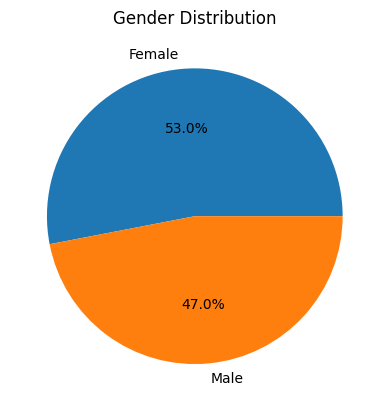

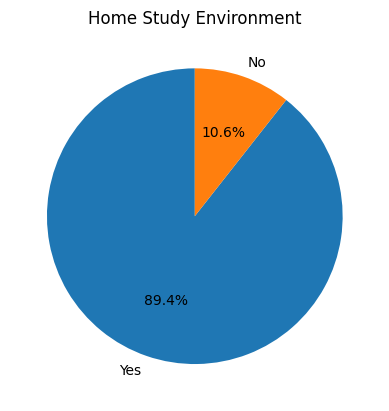

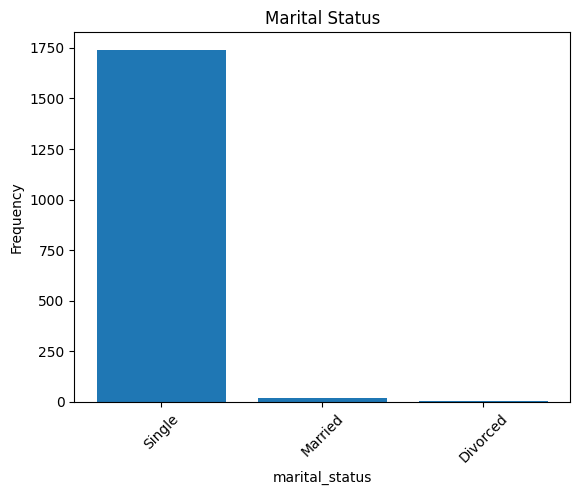

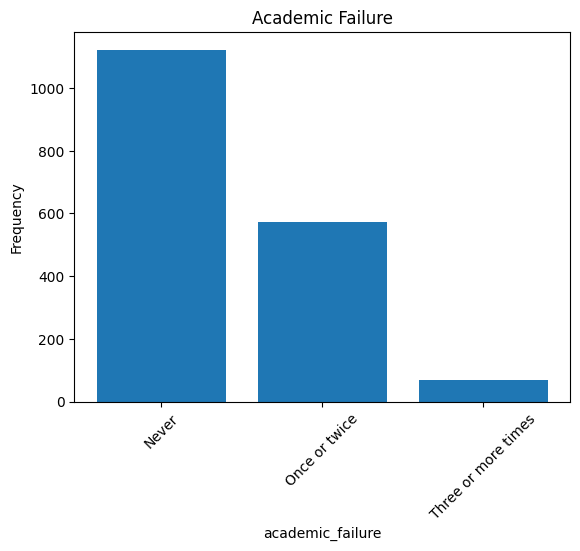

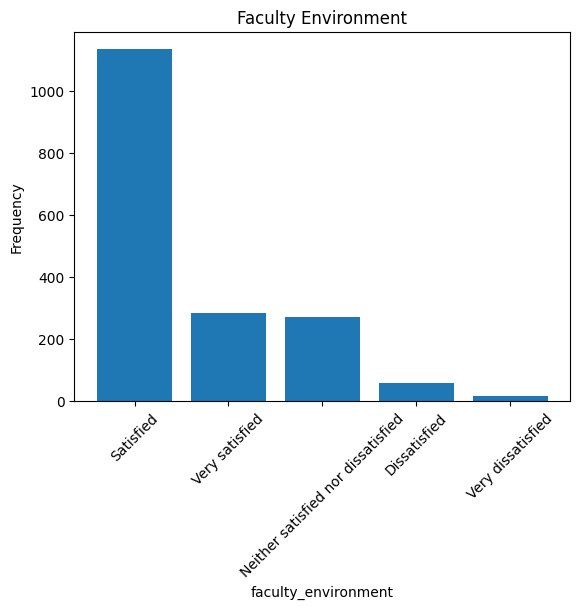

In [18]:
import matplotlib.pyplot as plt
#Gender Pie chart
plt.figure()
plt.pie(gender_table["Frequency"],
        labels=gender_table["gender"],
        autopct='%1.1f%%')

plt.title("Gender Distribution")
plt.show()

import matplotlib.pyplot as plt

#Home study env pie chart

plt.figure()
plt.pie(home_env_table["Frequency"],
        labels=home_env_table["home_environment"],
        autopct='%1.1f%%',
        startangle=90)

plt.title("Home Study Environment")
plt.show()

plot_bar(marital_table, "marital_status", "Marital Status")
plot_bar(failure_table, "academic_failure", "Academic Failure")
plot_bar(faculty_env_table, "faculty_environment", "Faculty Environment")

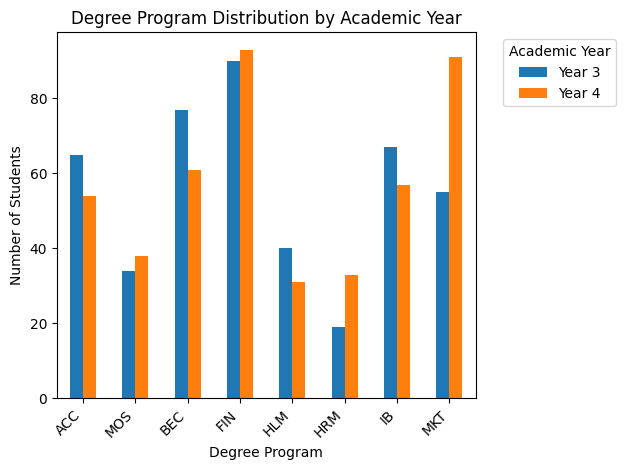

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Create pivot table
pivot_table = pd.pivot_table(
    df,
    index="degree_program",
    columns="academic_year",
    aggfunc="size",
    fill_value=0
)

# Rename degree programs (short labels)
rename_dict = {
    "B.B.A. (Hons) in Accounting": "ACC",
    "B.B.A. (Hons) in Business Administration": "MOS",
    "B.B.A. (Hons) in Business Economics": "BEC",
    "B.B.A. (Hons) in Finance": "FIN",
    "B.B.A. (Hons) in Hospitality and Leisure Management": "HLM",
    "B.B.A. (Hons) in Human Resource Management": "HRM",
    "B.B.A. (Hons) in International Business": "IB",
    "B.B.A. (Hons) in Marketing": "MKT"
}

pivot_table.rename(index=rename_dict, inplace=True)

# Plot
ax = pivot_table.plot(kind="bar")

plt.title("Degree Program Distribution by Academic Year")
plt.xlabel("Degree Program")
plt.ylabel("Number of Students")
plt.xticks(rotation=45, ha="right")

# Move legend outside
plt.legend(title="Academic Year", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

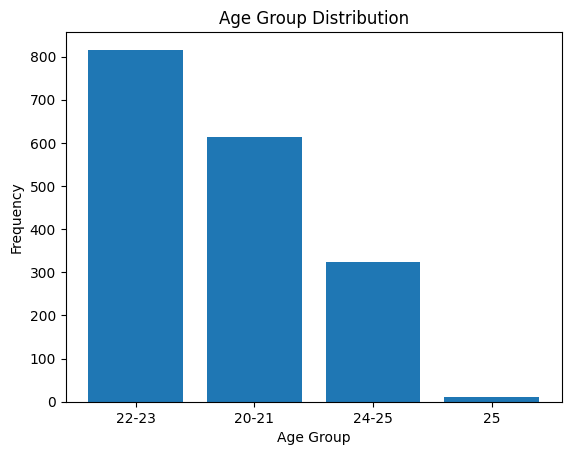

In [20]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(age_table['age_group'], age_table['Frequency'])
plt.xlabel('Age Group')
plt.ylabel('Frequency')
plt.title('Age Group Distribution')
plt.show()

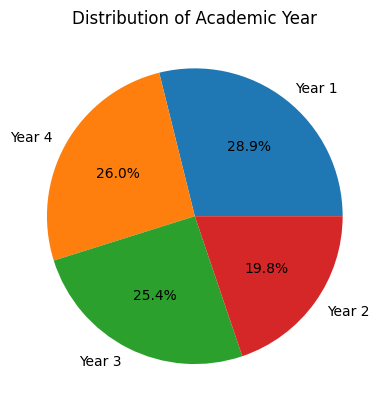

In [21]:
import matplotlib.pyplot as plt

# Data
labels = ['Year 1', 'Year 4', 'Year 3', 'Year 2']
sizes = [509, 458, 447, 349]

# Plot
plt.figure()
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of Academic Year')

plt.show()